Lecture: AI I - Advanced 

Previous:
[**Chapter 2.1: Regularization**](../01_regularization.ipynb)

---

# Exercise 2.1: Regularization

> Hint: When doing the exercises put your solution in the designated "Solution" section:
> ```python
> # Solution (put your code here)
> ```

## Task 1: Diabetes Regression with Multi-Layer Perceptron with Regularization

The diabetes dataset contains 442 samples with 10 baseline variables (age, sex, BMI, blood pressure, and 6 blood serum measurements). The target is a quantitative measure of disease progression one year after baseline.

**Tasks**
- Data Exploration & Understanding
- Data preparation
- Build Model a Multi-Layer Perceptron for regression and add regularization
- Train the model 
- Evaluate the model performance using appropriate regression metrics (e.g. MSE, MAE) and Tensorboard

In [113]:
# prerequisites (don't edit this block)
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target

In [114]:
# Solution (put your code here)
import torch

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader


X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42) #stratify=y doesn't work for regression problems, so we can't use it here
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) #stratify=y_temp doesn't work for regression problems, so we can't use it here

batch_size = 16
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)), batch_size=batch_size)

In [115]:
import torch.nn as nn
import torch.nn.functional as F

class BaselineModel(nn.Module):
    """Baseline model WITHOUT regularization - prone to overfitting"""
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [116]:
class L2RegularizedModel(nn.Module):
    """Model with L2 regularization (weight decay)
    Constraint-based: Penalizes large weights"""
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [117]:
class DropoutModel(nn.Module):
    """Model with Dropout
    Architecture-based: Randomly deactivates neurons during training"""
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=3, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Dropout after first layer
        x = F.relu(self.fc2(x))
        x = self.dropout(x)  # Dropout after second layer
        x = self.fc3(x)
        return x

In [118]:
class BatchNormModel(nn.Module):
    """Model with Batch Normalization
    Architecture-based: Normalizes activations, acts as regularizer"""
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

In [119]:
models = {
    "Baseline (No Regularization)": BaselineModel(input_dim=10, hidden_dim=64, output_dim=1),
    "L2 Regularization": L2RegularizedModel(input_dim=10, hidden_dim=64, output_dim=1),
    "Dropout": DropoutModel(input_dim=10, hidden_dim=64, output_dim=1),
    "Batch Normalization": BatchNormModel(input_dim=10, hidden_dim=64, output_dim=1),
}

In [120]:
def train_epoch(model, train_loader, criterion, optimizer):
    """Train for one epoch"""
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    
    avg_loss = train_loss / len(train_loader.dataset)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, data_loader, criterion):
    """Evaluate the model"""
    model.eval()
    eval_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            eval_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)
    
    avg_loss = eval_loss / len(data_loader.dataset)
    accuracy = correct / total
    return avg_loss, accuracy


def train_model(model, train_loader, val_loader, num_epochs=200, lr=0.01, weight_decay=0.0):
    """Complete training loop"""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer) # Train
        val_loss, val_acc = evaluate(model, val_loader, criterion)  # Validate
        
        # Store history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        # Print progress
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    return history

In [ ]:
results = {}
for name, model in models.items():
    print(f"\nTraining: {name}")
    print("-" * 70)
    
    history = train_model(
        model, 
        train_loader, 
        val_loader, 
        num_epochs=200,
        lr=0.01,
        weight_decay=0.01 if "L2" in name or "Combined" in name else 0.0
    )
    test_loss, _ = evaluate(model, test_loader, nn.MSELoss())
    results[name] = {
        "history": history,
        "test_loss": test_loss,
        "test_acc": None # regression problem doesn't have accuracy metric, so we set it to None
    }


Training: Baseline (No Regularization)
----------------------------------------------------------------------


/workspaces/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/workspaces/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([9])) that is different to the input size (torch.Size([9, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/workspaces/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return 

Epoch  50/200 | Train Loss: 6012.5888, Acc: 0.0000 | Val Loss: 5738.8595, Acc: 0.0000
Epoch 100/200 | Train Loss: 6124.8994, Acc: 0.0000 | Val Loss: 5804.4502, Acc: 0.0000
Epoch 150/200 | Train Loss: 6012.7794, Acc: 0.0000 | Val Loss: 5774.6433, Acc: 0.0000
Epoch 200/200 | Train Loss: 6115.6535, Acc: 0.0000 | Val Loss: 5797.1681, Acc: 0.0000

Training: L2 Regularization
----------------------------------------------------------------------
Epoch  50/200 | Train Loss: 6034.8930, Acc: 0.0000 | Val Loss: 5734.3821, Acc: 0.0000
Epoch 100/200 | Train Loss: 6115.8015, Acc: 0.0000 | Val Loss: 5765.9974, Acc: 0.0000
Epoch 150/200 | Train Loss: 6028.8285, Acc: 0.0000 | Val Loss: 5747.9947, Acc: 0.0000
Epoch 200/200 | Train Loss: 6013.1292, Acc: 0.0000 | Val Loss: 5793.8105, Acc: 0.0000

Training: Dropout
----------------------------------------------------------------------
Epoch  50/200 | Train Loss: 6494.5726, Acc: 0.0000 | Val Loss: 5729.1425, Acc: 0.0000
Epoch 100/200 | Train Loss: 6347.560

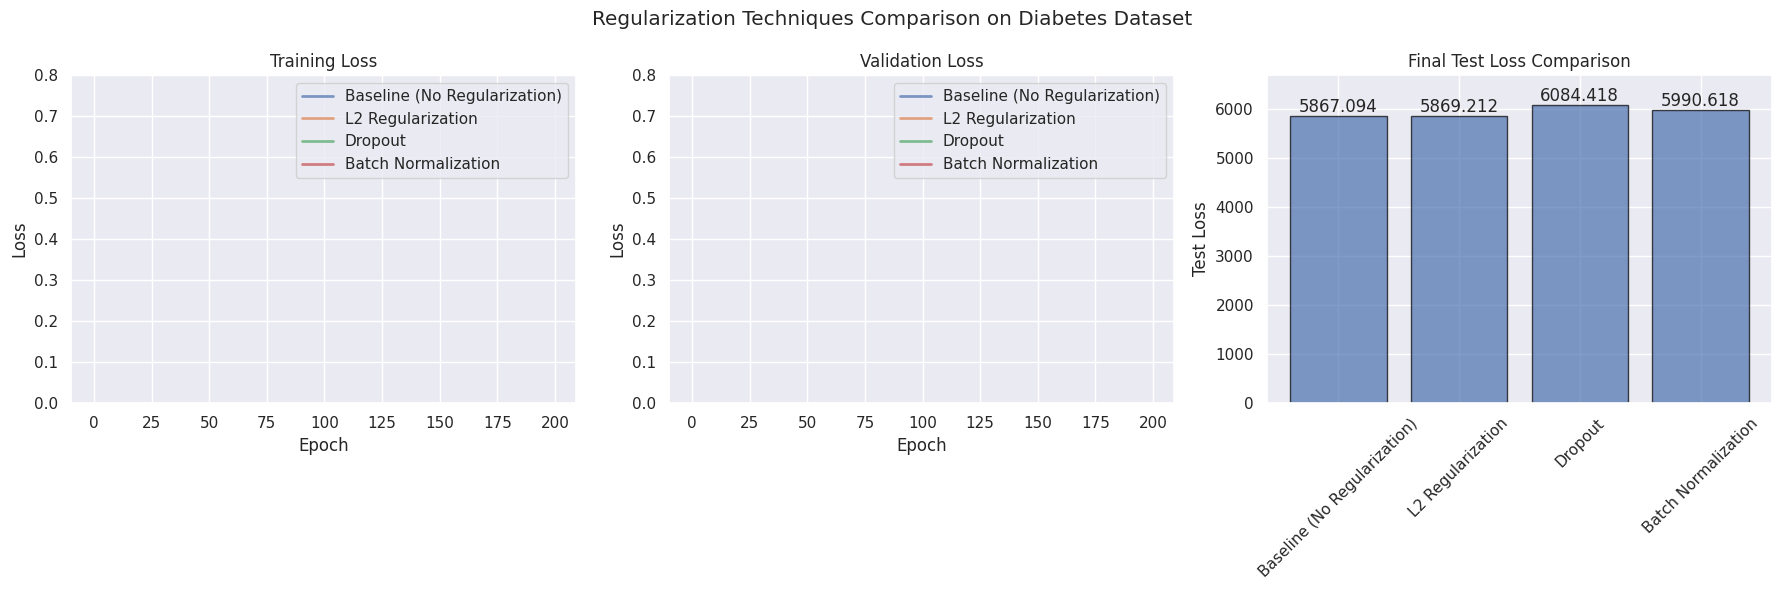

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 100  # keep pixel size reasonable

# Create comprehensive comparison visualization
fig, (train_ax, val_ax, test_ax) = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
fig.suptitle("Regularization Techniques Comparison on Diabetes Dataset")


# 1. Training Loss Comparison
for name, result in results.items():
    train_ax.plot(result["history"]["train_loss"], label=name, alpha=0.7, linewidth=2)
train_ax.set(title="Training Loss", xlabel="Epoch", ylabel="Loss", ylim=(0, .8))
train_ax.legend()

# 2. Validation Loss Comparison
for name, result in results.items():
    val_ax.plot(result["history"]["val_loss"], label=name, alpha=0.7, linewidth=2)
val_ax.set(title="Validation Loss", xlabel="Epoch", ylabel="Loss", ylim=(0, .8))
val_ax.legend()

# 3. Final Test Loss Comparison (Bar Chart)
names = list(results.keys())
test_losses = [results[name]["test_loss"] for name in names]

# Guard against non-finite or extreme values
finite_losses = [loss for loss in test_losses if np.isfinite(loss)]
max_loss = max(finite_losses) if finite_losses else 1.0

bars = test_ax.bar(range(len(names)), test_losses, alpha=0.7, edgecolor="black")
test_ax.set_ylim(0, max_loss * 1.1)

for bar, loss in zip(bars, test_losses):
    test_ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height(),
        f"{loss:.3f}",
        ha="center",
        va="bottom",
        clip_on=True
    )

test_ax.set(title="Final Test Loss Comparison", ylabel="Test Loss", xticks=range(len(names)))
test_ax.set_xticklabels(names, rotation=45)

fig.tight_layout()

Regression hat keine Accuracy

In [ ]:
# Test case (don't edit this block)
assert True

---

Lecture: AI I - Advanced 

Next: [**Chapter 2.2: Optimization**](../02_optimization.ipynb)